In [1]:
import math 
import numpy as np
import numpy.random as npr
from pylab import plt, mpl

In [2]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

In [3]:
npr.seed(100)
np.set_printoptions(precision=4)

In [4]:
npr.rand(10)

array([0.5434, 0.2784, 0.4245, 0.8448, 0.0047, 0.1216, 0.6707, 0.8259,
       0.1367, 0.5751])

In [5]:
npr.rand(5,5)

array([[0.8913, 0.2092, 0.1853, 0.1084, 0.2197],
       [0.9786, 0.8117, 0.1719, 0.8162, 0.2741],
       [0.4317, 0.94  , 0.8176, 0.3361, 0.1754],
       [0.3728, 0.0057, 0.2524, 0.7957, 0.0153],
       [0.5988, 0.6038, 0.1051, 0.3819, 0.0365]])

In [6]:
a = 5.
b = 10.

In [7]:
npr.rand(10) * (b - a) + a

array([9.4521, 9.9046, 5.2997, 9.4527, 7.8845, 8.7124, 8.1509, 7.9092,
       5.1022, 6.0501])

In [8]:
npr.rand(5, 5) * (b - a) + a

array([[7.7234, 8.8456, 6.2535, 6.4295, 9.262 ],
       [9.875 , 9.4243, 6.7975, 7.9943, 6.774 ],
       [6.701 , 5.8904, 6.1885, 5.2243, 7.5272],
       [6.8813, 7.964 , 8.1497, 5.713 , 9.6692],
       [9.7319, 8.0115, 6.9388, 6.8159, 6.0217]])

In [9]:
sample_size = 500
rn1 = npr.rand(sample_size, 3)
rn2 = npr.randint(0, 10, sample_size)
rn3 = npr.sample(size = sample_size)
a = [0, 25, 50, 75, 100]
rn4 = npr.choice(a, size=sample_size)

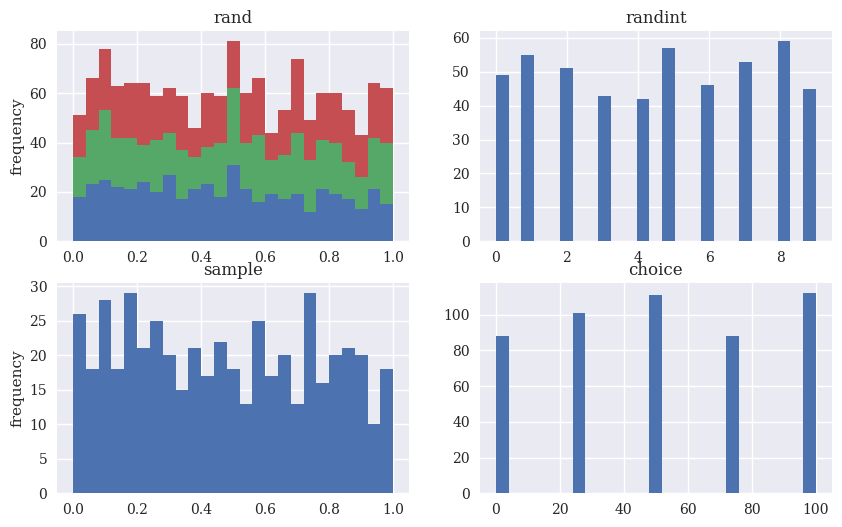

In [10]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, 
                                             figsize=(10,6))
ax1.hist(rn1, bins=25, stacked=True)
ax1.set_title('rand')
ax1.set_ylabel('frequency')
ax2.hist(rn2, bins=25)
ax2.set_title('randint')
ax3.hist(rn3, bins=25)
ax3.set_title('sample')
ax3.set_ylabel('frequency')
ax4.hist(rn4, bins=25)
ax4.set_title('choice');
plt.show()

In [11]:
sample_size = 500
nr1 = npr.standard_normal(sample_size)
rn2 = npr.normal(100, 20, sample_size)
rn3 = npr.chisquare(df=0.5, size=sample_size)
rm4 = npr.poisson(lam=1.0, size=sample_size)

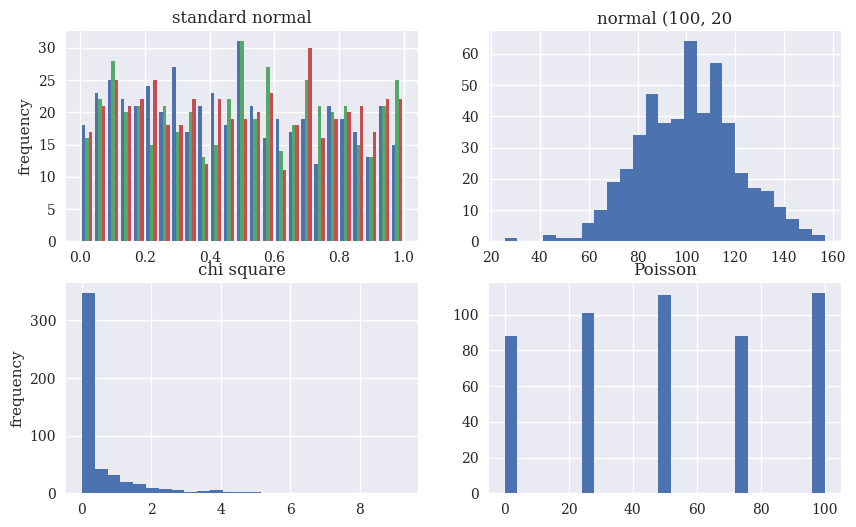

In [12]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, 
                                             figsize=(10,6))
ax1.hist(rn1, bins=25)
ax1.set_title('standard normal')
ax1.set_ylabel('frequency')
ax2.hist(rn2, bins=25)
ax2.set_title('normal (100, 20')
ax3.hist(rn3, bins=25)
ax3.set_title('chi square')
ax3.set_ylabel('frequency')
ax4.hist(rn4, bins=25)
ax4.set_title('Poisson');
plt.show()

<span style='fontsize:17px'><b>Statistical Distribution Profiling and Visualization</b>

The following implementation utltizes a 'matplotlib' subplot framework to conduct a comparative analysis of diverse probability distributions, a critical diagnosis phase in verifying that stochastic generators align with the underlying assumptions of a financial model.

* <b>Standard Normal ($rn_1$):</b> Implements the $N(0, 1)$ distribution, serving as the foundational driver for Brownian motion and the 'random walk' hypothesis in equity price modeling.
* <b>Paramterized Normal ($rn_2$):</b> Generates a Gaussian distribution with a custom mean ($\mu=100$) and standard deviation ($\sigma=20$), allowing for the simulation of specific asset price levels or interest rate targets.
* <b>Chi-Square ($rn_3$):</b> Displays extreme right-skewness (at $df=0.5$), frequently employed in fixed-come analytics to model stochastic volatility and non-negative interest rate processes like the CIR model.
* <b>Poisson($rn_4$):</b> A discrete distribution modeling the frequency of independent events, essential for Jump-Diffusion frameworks that capture infrequent, high-impact 'shocks' such as market crashes.
* <b>Visualization Strategy:</b> The $2 \times 2$ suplot configuration facilitates simultaneous evaluation of central tendency and tail behavior, using granular density estimation to ensure the sample size ($n=500$) captures the intended statistical profile.

In [13]:
S0 = 100
r = 0.05
sigma = 0.25
T = 2.0
I = 10000
ST1= S0 * np.exp((r - 0.5 * sigma ** 2) * T +
                 sigma * math.sqrt(T) * npr.standard_normal(I))

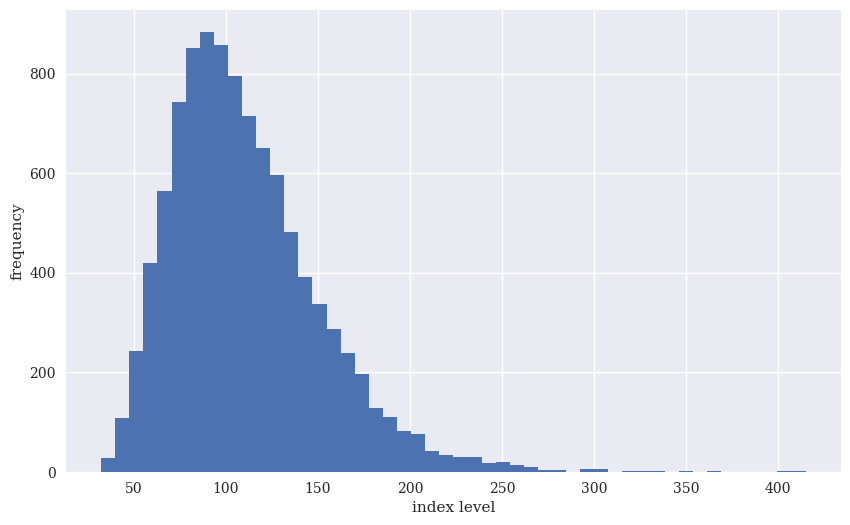

In [14]:
plt.figure(figsize=(10,6))
plt.hist(ST1, bins = 50)
plt.xlabel('index level')
plt.ylabel('frequency')
plt.show()

In [15]:
ST2 = S0 * npr.lognormal((r - 0.5 * sigma ** 2) * T, 
                         sigma * math.sqrt(T), size=I)

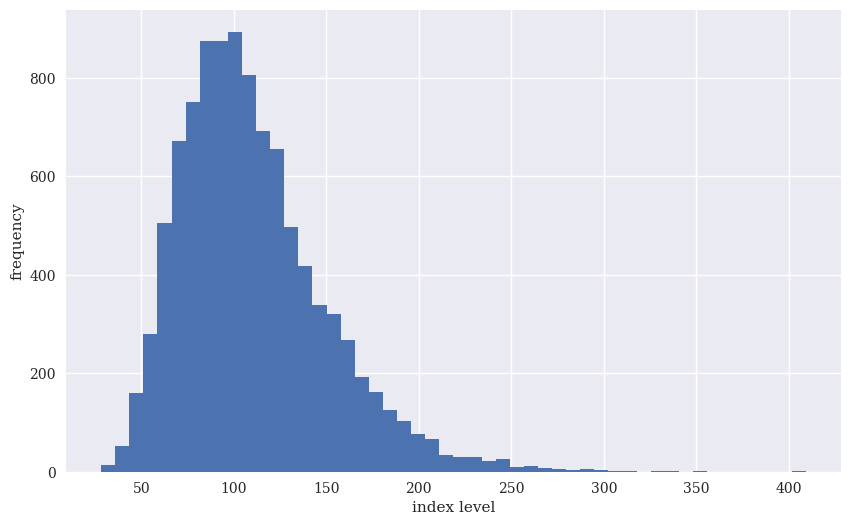

In [16]:
plt.figure(figsize=(10,6))
plt.hist(ST2, bins = 50)
plt.xlabel('index level')
plt.ylabel('frequency')
plt.show()

In [17]:
import scipy.stats as scs

In [18]:
def print_statistics(a1, a2):
    ''' Prints selected statistics.

    Parameters
    ===============
    a1, a2: ndarray objects 
    results objects from simulations
    '''
    sta1 = scs.describe(a1)
    sta2 = scs.describe(a2)
    print('%14s %14s %14s' % ('statistic', 'data set 1', 'data set 2'))
    print(45 * '-')
    print('%14s %14.3f %14.3f' % ('size', sta1[0], sta2[0]))
    print('%14s %14.3f %14.3f' % ('min', sta1[1][0], sta2[1][0]))
    print('%14s %14.3f %14.3f' % ('max', sta1[1][1], sta2[1][1]))
    print('%14s %14.3f %14.3f' % ('mean', sta1[2], sta2[2]))
    print('%14s %14.3f %14.3f' % ('std', np.sqrt(sta1[3]), np.sqrt(sta2[3])))
    print('%14s %14.3f %14.3f' % ('skew', sta1[4], sta2[4]))
    print('%14s %14.3f %14.3f' % ('kurtosis', sta1[5], sta2[5]))

In [19]:
print_statistics(ST1, ST2)

     statistic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min         32.327         28.230
           max        414.825        409.110
          mean        110.730        110.431
           std         40.300         39.878
          skew          1.122          1.115
      kurtosis          2.438          2.217


<span style='fontsize:17px'><b>Comparative Simulation Analysis: GBM vs. Log-Normal Sampling</b>

This section evaluates two distinct methodologies for generating terminal asset price distributions, validating the mathematical consistency between manual stochastic equations and built-in library functions.

* <b>Simulation Framework (ST1):</b> Uses a manual implementation of the Geometric Brownian Motion (GBM) closed-form solution: $S_t = \exp((r - 0.5\sigma^2)T + \sigma\sqrt{T}z)$. This approach offers granular control over the different components.
* <b>Direct Sampling (ST2):</b> Employs 'npr.lognormal' to achieve the same distribution result. This method is computationally more efficient and serves as a benchmark for the manual GBM implementation.
* <b>Lognormal Characteristics:</b> Both histograms exhibit 'fat-tail' behavior and positive skewness typical of equity markets, where prices are bounded at zero but possess theoretical infinite upside.
* <b>Statistical Convergence:</b> The 'print_statistics' table confirms that with $I=10,000$ paths.
* <b>Error Attributions:</b> The minor differences between Data Set 1 and Data Set 2 represent the <b>sampling errors</b> inherent in Monte Carlo methods. These variances would theoretically converge to zero as the number of paths $I$ approaches infinity.

In [20]:
I = 10000
M = 50
dt = T / M
S = np.zeros((M + 1, I))
S[0] = S0
for t in range(1, M + 1):
    S[t] = S[t - 1] * np.exp((r - 0.5 * sigma ** 2) * dt +
                             sigma * math.sqrt(dt) * npr.standard_normal(I))

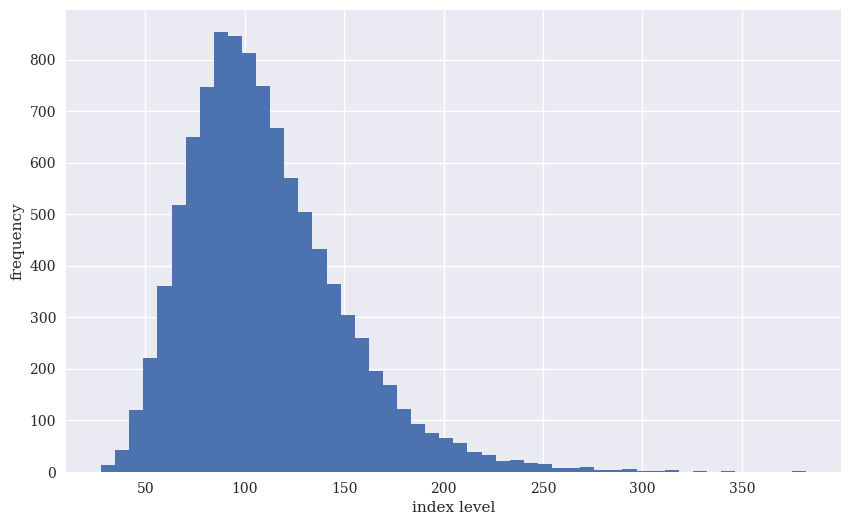

In [21]:
plt.figure(figsize=(10,6))
plt.hist(S[-1], bins=50)
plt.xlabel('index level')
plt.ylabel('frequency')
plt.show()

In [22]:
print_statistics(S[-1], ST2)

     statistic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min         27.746         28.230
           max        382.096        409.110
          mean        110.423        110.431
           std         39.179         39.878
          skew          1.069          1.115
      kurtosis          2.028          2.217


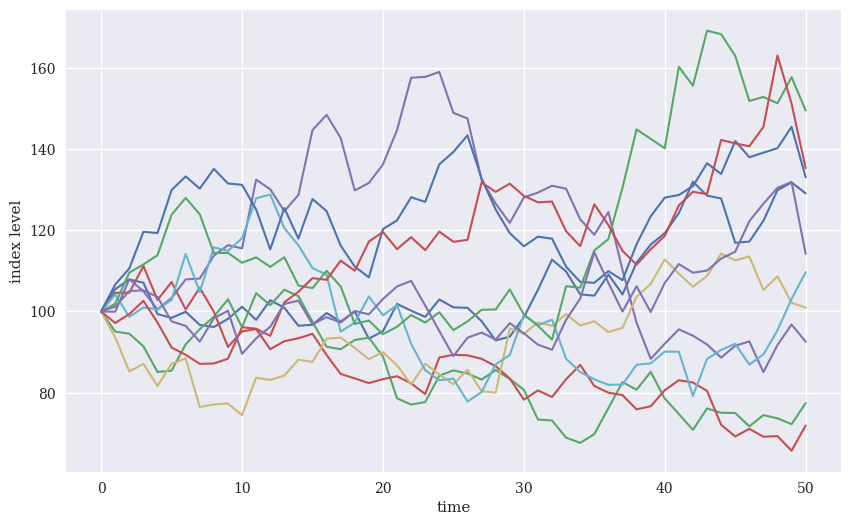

In [23]:
plt.figure(figsize=(10,6))
plt.plot(S[:, :10], lw=1.5)
plt.xlabel('time')
plt.ylabel('index level')
plt.show()

In [24]:
x0 = 0.05
kappa = 3.0
theta = 0.02
sigma = 0.1
I = 10000
M = 50
dt = T/M

In [25]:
def srd_euler():
    xh = np.zeros((M + 1, I))
    x = np.zeros_like(xh)
    xh[0] = x0
    x[0] = x0
    for t in range(1, M + 1):
        xh[t] = (xh[t-1] +
                 kappa * (theta - np.maximum(xh[t-1],0)) * dt + 
                 sigma * np.sqrt(np.maximum(xh[t - 1], 0)) * 
                 math.sqrt(dt) * npr.standard_normal(I))
    x = np.maximum(xh, 0)
    return x 
x1 = srd_euler()

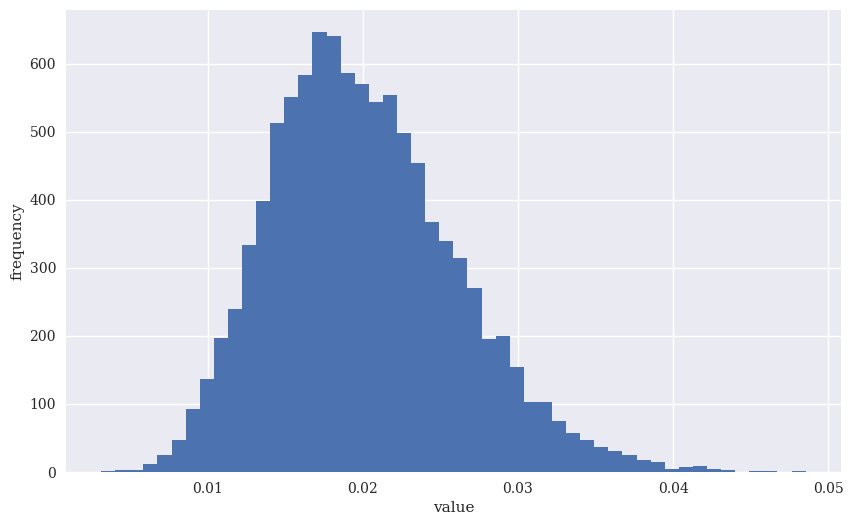

In [26]:
plt.figure(figsize=(10,6))
plt.hist(x1[-1], bins=50)
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

In [27]:
def srd_exact():
    x = np.zeros((M + 1, I))
    x[0] = x0
    for t in range(1, M + 1):
        df = 4 * theta * kappa / sigma ** 2
        c = (sigma ** 2 * ( 1 - np.exp(-kappa * dt))) / (4 * kappa)
        nc = np.exp(-kappa * dt) / c * x[t - 1]
        x[t] = c *npr.noncentral_chisquare(df, nc, size = I)
    return x 
x2 = srd_exact()

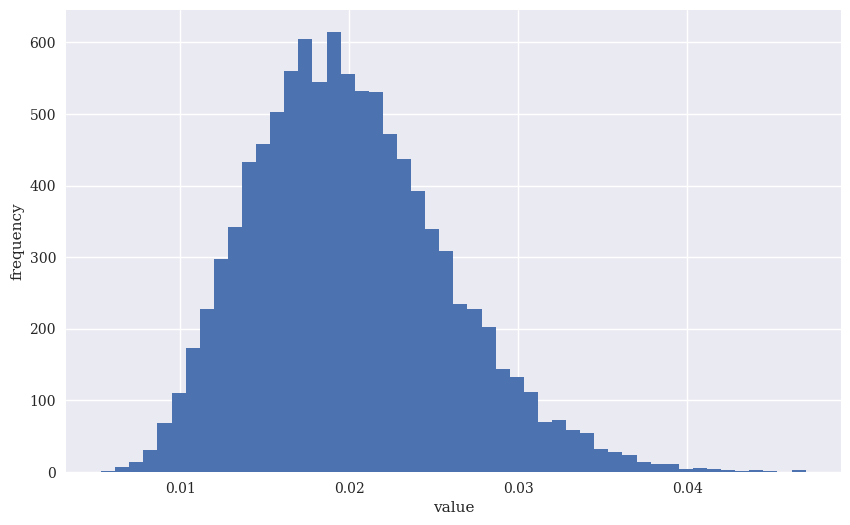

In [28]:
plt.figure(figsize=(10,6))
plt.hist(x2[-1], bins=50)
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

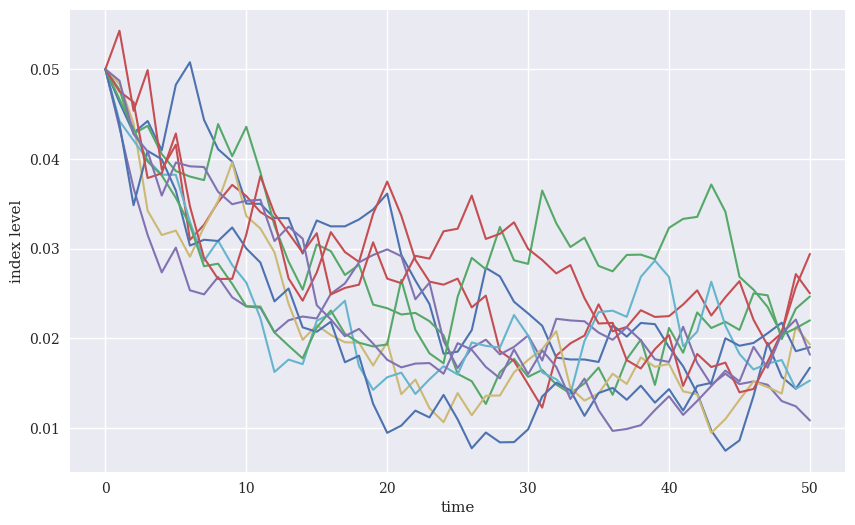

In [29]:
plt.figure(figsize=(10,6))
plt.plot(x2[:, :10], lw=1.5)
plt.xlabel('time')
plt.ylabel('index level')
plt.show()

In [30]:
print_statistics(x1[-1], x2[-1])

     statistic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min          0.003          0.005
           max          0.049          0.047
          mean          0.020          0.020
           std          0.006          0.006
          skew          0.529          0.532
      kurtosis          0.289          0.273


In [31]:
I = 250000
%time x1 = srd_euler()

CPU times: total: 656 ms
Wall time: 686 ms


In [32]:
%time x2 = srd_exact()

CPU times: total: 938 ms
Wall time: 953 ms


In [33]:
print_statistics(x1[-1], x2[-1])

     statistic     data set 1     data set 2
---------------------------------------------
          size     250000.000     250000.000
           min          0.002          0.003
           max          0.071          0.055
          mean          0.020          0.020
           std          0.006          0.006
          skew          0.563          0.579
      kurtosis          0.492          0.520


<span style='fontsize:17px'><b>Comparitive Simulation Analysis: Euler vs. Exact SRD</b>

This section evaluates the performance and mathematical integrity of two distinct methodologies for simulating the <b>Cox-Ingersoll-Ross (CIR)</b> square-root diffusion process.

* <b>Simulation Framework (x1):</b> Uses a manual implementation of the <b>Euler Maruyama</b> discretization. It approximates the path by taking $M$ small linear steps and requires a 'safety net' ('np.maximum') to prevent the math from breaking if the process drifts negative.
* <b>Exact Sampling (x2):</b> Employs 'npr.noncentral_chisquare' to achieve the same terminal result. This is the 'perfect' mathematical solution that draws the next state directly from the theoretical probability density, inherently respecting the zero-bound.
* <b>Mean Reversion Profile:</b> Both models successfully demonstrate the 'pull' toward the long-term mean ($\theta = 0.02$). Even though they start at $x_0 = 0.05$, the paths aggressively decary toward the target level over time.
* <b>Statistical Convergence:</b> The 'print_statistics' table confirms that with $I = 250,000$ paths, both methods to converge to a nearly identical mean ($0.020$) and standard deviation ($0.006$) 

In [34]:
S0 = 100.
r = 0.05
v0 = 0.1
kappa = 3.0
theta = 0.25
sigma = 0.1
rho = 0.6
T = 1.0

In [35]:
corr_mat = np.zeros((2,2))
corr_mat[0,:] = [1.0, rho]
corr_mat[1,:] = [rho, 1.0]
cho_mat = np.linalg.cholesky(corr_mat)

In [36]:
cho_mat

array([[1. , 0. ],
       [0.6, 0.8]])

In [37]:
M = 50
I = 10000
dt = T/M 

In [38]:
ran_num = npr.standard_normal((2, M +1, I))

In [39]:
v = np.zeros_like(ran_num[0])
vh = np.zeros_like(v)

In [40]:
v[0] = v0
vh[0] = v0

In [41]:
for t in range(1, M + 1):
    ran = np.dot(cho_mat, ran_num[:, t, :])
    vh[t] = (vh[t - 1] + 
    kappa * (theta - np.maximum(vh[t-1],0)) * dt +
    sigma * np.sqrt(np.maximum(vh[t - 1], 0)) *
    math.sqrt(dt) * ran[1])

In [42]:
v = np.maximum(vh,0)

In [43]:
S = np.zeros_like(ran_num[0])
S[0] = S0
for t in range(1, M + 1):
    ran = np.dot(cho_mat, ran_num[:, t, :])
    S[t] = S[t - 1] * np.exp((r - 0.5 * v[t]) * dt + 
    np.sqrt(v[t]) * ran[0] * np.sqrt(dt))

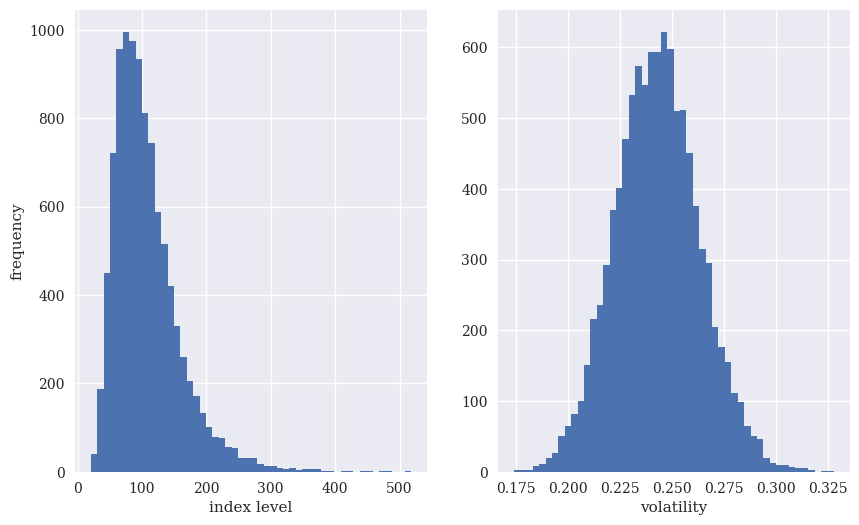

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))
ax1.hist(S[-1], bins=50)
ax1.set_xlabel('index level')
ax1.set_ylabel('frequency')
ax2.hist(v[-1],bins=50)
ax2.set_xlabel('volatility')
plt.show()

In [45]:
print_statistics(S[-1], v[-1])

     statistic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min         20.556          0.174
           max        517.798          0.328
          mean        107.843          0.243
           std         51.341          0.020
          skew          1.577          0.124
      kurtosis          4.306          0.048


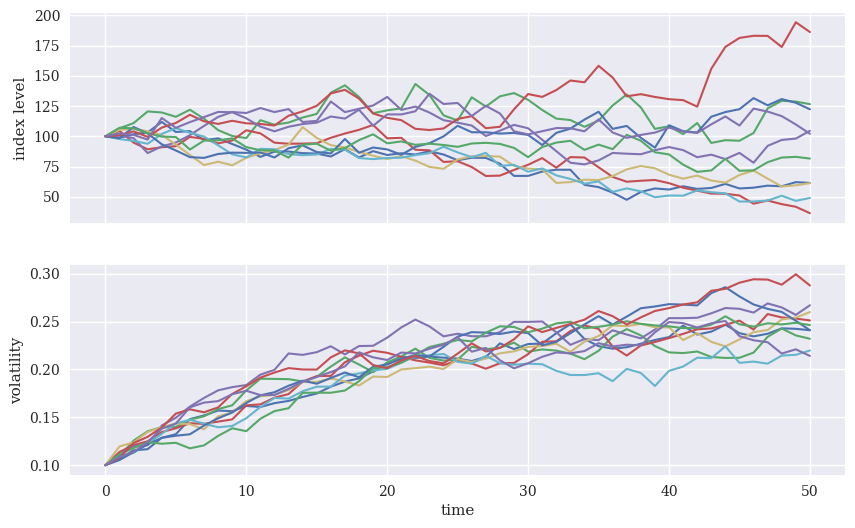

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True,
                               figsize=(10,6))
ax1.plot(S[:, :10], lw=1.5)
ax1.set_ylabel('index level')
ax2.plot(v[:, :10], lw=1.5)
ax2.set_xlabel('time')
ax2.set_ylabel('volatility')
plt.show()

In [73]:
S0 = 100
r = 0.05 
sigma = 0.2
lamb = 0.75
mu = -0.6
delta = 0.25
rj = lamb * (math.exp(mu + 0.5 * delta ** 2) - 1)

In [74]:
T = 1.0
M = 50
I = 10000
dt = T/M

In [75]:
S = np.zeros((M + 1, I))
S[0] = S0
sn1 = npr.standard_normal((M + 1, I))
sn2 = npr.standard_normal((M + 1, I))
poi = npr.poisson(lamb * dt, (M + 1, I))
for t in range(1, M + 1, 1):
    S[t] = S[t - 1] * (np.exp((r - rj - 0.5 * sigma ** 2) * dt +
                              sigma * math.sqrt(dt) * sn1[t]) +
                       (np.exp(mu + delta * sn2[t]) - 1) *
                       poi[t])
    S[t] = np.maximum(S[t], 0)

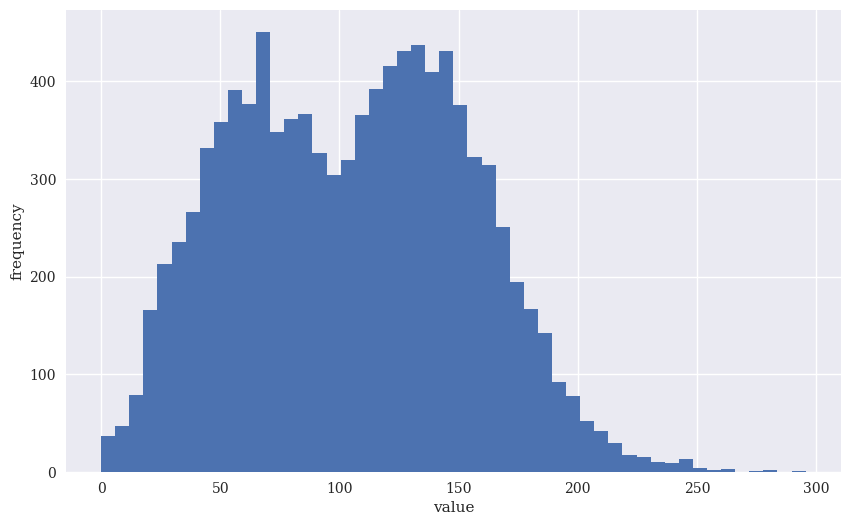

In [76]:
plt.figure(figsize=(10,6))
plt.hist(S[-1], bins=50)
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

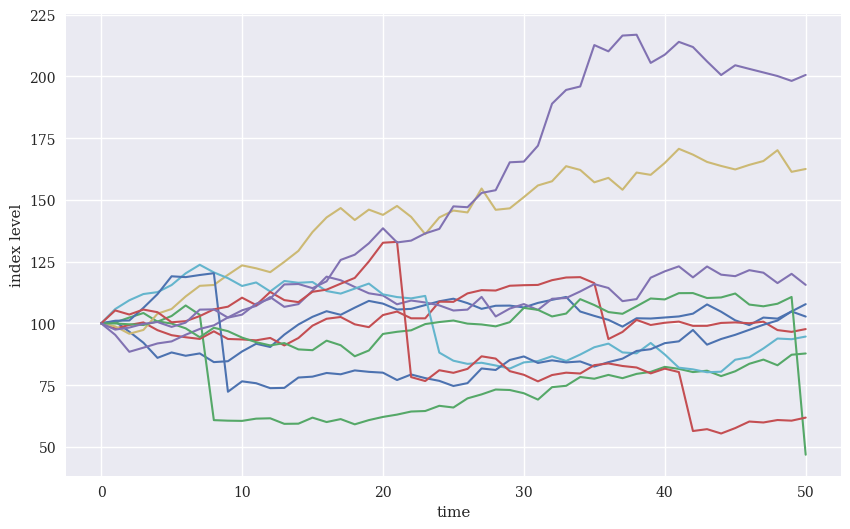

In [78]:
plt.figure(figsize=(10,6))
plt.plot(S[:, :10], lw =1.5)
plt.xlabel('time')
plt.ylabel('index level')
plt.show()

<span style='fontsize:17px'><b>Merton Jump Diffusion Analysis: The Black Box</b>

This section evaluates the terminal distribution of an asset governed by a jump-diffusion stochastic process. By calibrating the jump intensity and magnitude, the simulation successfully recovers the characteristic bimodal density of the Merton model.

* <b>Binomial Distribution Dynamics:</b> The resulting histrogram illustrates a clear regime-switching topology. The primary mode, centered near **$S_t \approx 130$**, represents diffusion paths, while the secondary mode near **$S_t \approx 60$** captures the density of the paths subject to discrete negative jumps.
* <b>Risk-Neutral Drift Compensation:</b> To satisfy the martingale property, the drift is adjusted by the compensator $\omega = \lambda (\mathbb{E}[e^J] - 1)$. This ensures that the instantaneous expected return of the jump diffusion process remains consistent with the risk-free rate **$r$**, preventing numerical decay.
* <b>Poisson-Normal Jump Characteristics:</b> The jump component utlitizes a Poisson arrival process with intensity $\lambda$, where the log-jump size is normally distributed $J \sim N(\mu, \delta^2)$. The convergence to a stable distributioun across 10,000 paths confirms the numerical robustness of the Euler-Maruyama discretization.
* <b>Pathwise Discontinuity:</b> Time-series analysis reveals the non-continuous nature of the trajectories. Unlike pure Geometric Brownian Motion, these paths exhibit finite-activity 'shocks', accuractely modeling the 'fat-tailed' risk and skewness observed in empirical market data.

In [80]:
print('%15s 15%s' % ('Mean', 'Std. Deviation'))
print(31 * '-')
for i in range (1, 31, 2):
    npr.seed(100)
    sn = npr.standard_normal(i ** 2 * 10000)
    print('%15.12f %15.12f' % (sn.mean(), sn.std()))

           Mean 15Std. Deviation
-------------------------------
 0.001150944833  1.006296354600
 0.002841204001  0.995987967146
 0.001998082016  0.997701714233
 0.001322322067  0.997771186968
 0.000592711311  0.998388962646
-0.000339730751  0.998399891450
-0.000228109010  0.998657429396
 0.000295768719  0.998877333340
 0.000257107789  0.999284894532
-0.000357870642  0.999456401088
-0.000528443742  0.999617831131
-0.000300171536  0.999445228838
-0.000162924037  0.999516059328
 0.000135778889  0.999611052522
 0.000182006048  0.999619405229


In [81]:
i ** 2 * 10000

8410000

In [83]:
sn = npr.standard_normal(int(10000 /2))
sn = np.concatenate((sn, -sn))

In [85]:
np.shape(sn)

(10000,)

In [86]:
sn.mean()

np.float64(3.1974423109204507e-18)

In [89]:
print('%15s 15%s' % ('Mean', 'Std. Deviation'))
print(31 * '-')
for i in range (1, 31, 2):
    npr.seed(1000)
    sn = npr.standard_normal(i ** 2 * int(10000 / 2))
    sn = np.concatenate((sn, -sn))
    print('%15.12f %15.12f' % (sn.mean(), sn.std()))

           Mean 15Std. Deviation
-------------------------------
 0.000000000000  1.009653753942
-0.000000000000  1.000413716783
 0.000000000000  1.002925061201
-0.000000000000  1.000755212673
 0.000000000000  1.001636910076
-0.000000000000  1.000726758438
-0.000000000000  1.001621265149
 0.000000000000  1.001203722778
-0.000000000000  1.000556669784
 0.000000000000  1.000113464185
-0.000000000000  0.999435175324
 0.000000000000  0.999356961431
-0.000000000000  0.999641436845
-0.000000000000  0.999642768905
-0.000000000000  0.999638303451


In [90]:
sn = npr.standard_normal(10000)

In [91]:
sn.mean()

np.float64(-0.001165998295162494)

In [92]:
sn.std()

np.float64(0.991255920204605)

In [95]:
sn_new = (sn - sn.mean()) / sn.std()

In [96]:
sn_new.mean()

np.float64(-2.3803181647963357e-17)

In [97]:
sn_new.std()

np.float64(0.9999999999999999)

In [99]:
def gen_sn (M, I, anti_paths=True, mo_match=True):
    if anti_paths is True:
        sn = npr.standard_normal((M + 1, int(I/2)))
        sn = np.concatenate((sn, -sn), axis=1)
    else:
        sn = npr.standard_normal((M + 1, I))
    if mo_match is True:
        sn = (sn - sn.mean()) / sn.std()
    return sn

In [100]:
S0 = 100.
r = 0.05
sigma = 0.25
T = 1.0
I = 50000

In [101]:
def gbm_mcs_stats(K):
    '''Valuation of European call option in Black-Scholes_Merton 
    by Monte Carlo Simulation (of index level at maturity)

    Parameters
    ==========
    K: float
    (positive) strike price of the option

    Returns
    =======
    C0: float
    estimated present value of the European call option
    '''
    sn = gen_sn(1, I)
    #simulate index level at maturity
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T 
                     + sigma * math.sqrt(T) * sn[1])
    # calculate payoff at maturity
    hT = np.maximum(ST - K, 0)
    # calculate MCS estimator
    C0 = math.exp(-r * T) * np.mean(hT)
    return C0

In [102]:
gbm_mcs_stats(K=105.)

np.float64(10.044221852841922)

In [103]:
M = 50

In [104]:
def gbm_mcs_dyna(K, option = 'call'):
    ''' Valuation of European options in Black-Scholes-Merton
    by Monte Carlo simulation (of index level paths)

    Parameters
    ==========
    K: float 
    (positive) strike price of the option
    option : string
    type of the option to be valued ('call', 'put')

    Returns
    =======
    C0: float
    estimated present value of European call option
    '''
    dt = T/M
    #simulation of index level paths
    S = np.zeros((M + 1, I))
    S[0] = S0
    sn =  gen_sn(M, I)
    for t in range(1, M + 1):
        S[t] = S[t - 1] * np.exp((r - 0.5 * sigma ** 2) * dt
                                 + sigma * math.sqrt(dt) * sn[t])
    #case-based payoff calculation
    if option =='call':
        hT = np.maximum(S[-1] - K, 0)
    else:
        hT = np.maximum(K - S[-1], 0)
    #calculation of MCS estimator
    C0 = math.exp(-r * T)* np.mean(hT)
    return C0

In [105]:
gbm_mcs_dyna(K=110, option='call')

np.float64(7.950008525028434)

In [106]:
gbm_mcs_dyna(K=110, option='put')

np.float64(12.629934942682004)